In [2]:
# 加载序列数据，准备训练多层循环神经网络。
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
data = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)
train_iter = data.train_dataloader()
vocab = data.vocab


In [4]:
# 构造两层 LSTM；num_layers 控制循环层堆叠深度。
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
device = d2l.try_gpu()
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers)
model = d2l.RNNLM(lstm_layer, vocab_size)
model = model.to(device)


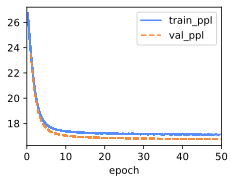

In [5]:
# 使用 Trainer 训练深层 LSTM，并启用梯度裁剪。
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)
